### Adım 1: MIT Sunucusundan Veriyi İndirme
Bu hücre, veriyi doğrudan kaynaktan (http://groups.csail.mit.edu/vision/LabelMe/NewImages/indoorCVPR_09.tar) indirmektedir.

In [ ]:
import os

# 1. MIT sunucusundan veri setini indir
print("MIT Indoor Scenes veri seti indiriliyor...")
!wget -nc http://groups.csail.mit.edu/vision/LabelMe/NewImages/indoorCVPR_09.tar

# 2. Tar dosyasını çıkart
print("Arşiv çıkartılıyor... Lütfen bekleyin.")
!tar -xf indoorCVPR_09.tar

print("Veri seti başarıyla indirildi ve çıkartıldı!")
print("Klasör içeriği kontrol ediliyor:")
!ls Images | head -n 5  # İlk 5 kategoriyi göster

MIT Indoor Scenes veri seti indiriliyor (Bu işlem biraz sürebilir, dosya boyutu ~2.4GB)...
--2026-05-30 15:48:39--  http://groups.csail.mit.edu/vision/LabelMe/NewImages/indoorCVPR_09.tar
Resolving groups.csail.mit.edu (groups.csail.mit.edu)... 128.52.131.233
Connecting to groups.csail.mit.edu (groups.csail.mit.edu)|128.52.131.233|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://groups.csail.mit.edu/vision/LabelMe/NewImages/indoorCVPR_09.tar [following]
--2026-05-30 15:48:40--  https://groups.csail.mit.edu/vision/LabelMe/NewImages/indoorCVPR_09.tar
Connecting to groups.csail.mit.edu (groups.csail.mit.edu)|128.52.131.233|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2592010240 (2.4G) [application/x-tar]
Saving to: ‘indoorCVPR_09.tar’

indoorCVPR_09.tar   100%[===================>]   2.41G  15.9MB/s    in 2m 42s  

2026-05-30 15:51:23 (15.3 MB/s) - ‘indoorCVPR_09.tar’ saved [2592010240/2592010240]

Arşiv çıkartıl

### Adım 2: Veriyi Train, Validation ve Test Olarak Bölme
Veri çıkartıldığında ana dizinde doğrudan bir Images klasörü oluşur. Yönergelerdeki 3000 Train (15 sınıf x 200), 750 Validation ve 750 Test kuralına göre bu orijinal resimleri processed_data adında düzenli bir klasör yapısına taşınıyor.

In [ ]:
import os
import shutil
import random
from glob import glob

# Yolların tanımlanması (Çıkan klasör adı doğrudan 'Images')
source_dir = 'Images'
base_dir = 'processed_data'

train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Train, Validation ve Test klasörlerini oluştur
if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

for d in [train_dir, val_dir, test_dir]:
    os.makedirs(d, exist_ok=True)

# 1. Sınıfları içerdikleri görsel sayısına göre say ve sırala
class_counts = {}
classes = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]

for cls in classes:
    cls_path = os.path.join(source_dir, cls)
    num_images = len(glob(os.path.join(cls_path, '*.jpg')))
    class_counts[cls] = num_images

# En çok görsele sahip 15 sınıfı seç
selected_classes = sorted(class_counts, key=class_counts.get, reverse=True)[:15]

print(f"En çok görsele sahip ve seçilen 15 Kategori:\n{selected_classes}\n")

# 2. Seçilen sınıflar için veriyi dağıt
for cls in selected_classes:
    # Alt klasörleri oluştur
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

    # Sınıftaki tüm resimlerin listesini al
    images = glob(os.path.join(source_dir, cls, '*.jpg'))

    # Rastgele dağılım için listeyi karıştır
    random.seed(42)
    random.shuffle(images)

    # İlk 200 -> Train, sonraki 50 -> Val, sonraki 50 -> Test
    train_imgs = images[:200]
    val_imgs = images[200:250]
    test_imgs = images[250:300]

    # Dosyaları ilgili klasörlere kopyala
    for img in train_imgs:
        shutil.copy(img, os.path.join(train_dir, cls, os.path.basename(img)))
    for img in val_imgs:
        shutil.copy(img, os.path.join(val_dir, cls, os.path.basename(img)))
    for img in test_imgs:
        shutil.copy(img, os.path.join(test_dir, cls, os.path.basename(img)))

print("Veri dağıtımı tamamlandı!")
print(f"Toplam Train Görseli: {len(glob(train_dir + '/*/*.jpg'))} (Beklenen: 3000)")
print(f"Toplam Validation Görseli: {len(glob(val_dir + '/*/*.jpg'))} (Beklenen: 750)")
print(f"Toplam Test Görseli: {len(glob(test_dir + '/*/*.jpg'))} (Beklenen: 750)")

En çok görsele sahip ve seçilen 15 Kategori:
['kitchen', 'livingroom', 'bedroom', 'airport_inside', 'bar', 'subway', 'casino', 'restaurant', 'warehouse', 'inside_subway', 'bakery', 'pantry', 'bookstore', 'toystore', 'corridor']

Veri dağıtımı tamamlandı!
Toplam Train Görseli: 3000 (Beklenen: 3000)
Toplam Validation Görseli: 750 (Beklenen: 750)
Toplam Test Görseli: 750 (Beklenen: 750)


### Adım 3: TensorFlow Data Loaders Hazırlanması
Görüntüleri RAM'e tek seferde yüklemek çökme yaratıyor. Bunun yerine, verileri diskten parça parça okuyan image_dataset_from_directory fonksiyonunu kullanacağız. Ayrıca aşırı öğrenmeyi (overfitting) engellemek için veri artırma (Data Augmentation) katmanları ekleniyor.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt


IMG_SIZE = (224, 224)
BASE_DIR = 'processed_data'

# Veri yükleme fonksiyonu
def get_datasets(batch_size):
    print(f"\n--- Veri setleri yükleniyor (Batch Size: {batch_size}) ---")

    train_ds = tf.keras.utils.image_dataset_from_directory(
        f'{BASE_DIR}/train',
        seed=42,
        image_size=IMG_SIZE,
        batch_size=batch_size,
        label_mode='categorical'
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        f'{BASE_DIR}/val',
        seed=42,
        image_size=IMG_SIZE,
        batch_size=batch_size,
        label_mode='categorical'
    )

    test_ds = tf.keras.utils.image_dataset_from_directory(
        f'{BASE_DIR}/test',
        seed=42,
        image_size=IMG_SIZE,
        batch_size=batch_size,
        label_mode='categorical'
    )

    # Performans optimizasyonu
    AUTOTUNE = tf.data.AUTOTUNE
    train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
    val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
    test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

    return train_ds, val_ds, test_ds

# Veri Artırma (Data Augmentation) Bloğu
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.1),
])

### Adım 4: CNN Mimarisinin Kurulması
Bu hücrede, temel bir CNN mimarisi tanımlıyoruz. Gereksinimleri karşılamak için dropout_rate ve learning_rate parametrelerini dışarıdan alan dinamik bir fonksiyon yazıyoruz.

In [ ]:
def build_model(dropout_rate=0.5, learning_rate=0.001):
    # Model girdisi
    inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

    # 1. Veri Artırma ve Normalizasyon
    x = data_augmentation(inputs)
    x = layers.Rescaling(1./255)(x)

    # 2. Konvolüsyon Katmanları
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # 3. Sınıflandırma (Classification) Katmanları
    x = layers.Flatten()(x)
    x = layers.Dense(512, activation='relu')(x)

    # İstenen Dropout denemeleri için parametrik Dropout katmanı
    x = layers.Dropout(dropout_rate)(x)

    # Çıktı katmanı (15 Sınıf, Softmax)
    outputs = layers.Dense(15, activation='softmax')(x)

    # Modeli oluşturma
    model = tf.keras.Model(inputs, outputs)

    # Derleme
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

test_model = build_model(dropout_rate=0.5, learning_rate=0.001)
test_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         7,695 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,086,735 (99.51 MB)

 Trainable params: 26,086,735 (99.51 MB)

 Non-trainable params: 0 (0.00 B)

### Deneme Eğitimi

In [ ]:
# Sadece test amaçlı batch_size = 32 ile verileri al
train_ds, val_ds, test_ds = get_datasets(batch_size=32)

# Temel parametrelerle modeli kur
model = build_model(dropout_rate=0.25, learning_rate=0.001)

# Sistemin çöküp çökmediğini görmek için 3 Epoch'luk deneme eğitimi
print("\n--- Sistem Testi: 3 Epoch'luk Eğitim Başlıyor ---")
history_test = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3
)
print("Sistem testi başarılı! Model veri alıp öğrenebiliyor.")


--- Veri setleri yükleniyor (Batch Size: 32) ---
Found 3000 files belonging to 15 classes.
Found 750 files belonging to 15 classes.
Found 750 files belonging to 15 classes.

--- Sistem Testi: 3 Epoch'luk Eğitim Başlıyor ---
Epoch 1/3
94/94 ━━━━━━━━━━━━━━━━━━━━ 29s 123ms/step - accuracy: 0.0903 - loss: 2.6927 - val_accuracy: 0.1080 - val_loss: 2.7037
Epoch 2/3
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.1367 - loss: 2.5267 - val_accuracy: 0.1493 - val_loss: 2.4997
Epoch 3/3
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.1550 - loss: 2.4651 - val_accuracy: 0.2227 - val_loss: 2.3164
Sistem testi başarılı! Model veri alıp öğrenebiliyor.


### Adım 5: Hiperparametre Grid Search ve Model Eğitimi
Bu hücre 24 kombinasyonu sırayla deneyecek, 100'er epoch eğitecek ve en yüksek Test Accuracy değerini veren modeli best_model_part1.keras olarak kaydedecektir.

In [ ]:
import csv
import numpy as np
import tensorflow as tf

# Ödevde istenen hiperparametre uzayı
batch_sizes = [32, 64]
learning_rates = [0.01, 0.001, 0.0001]
dropout_rates = [0.2, 0.3, 0.4, 0.5]
EPOCHS = 100

# Sonuçların loglanması
log_file = 'grid_search_results.csv'
with open(log_file, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['Batch_Size', 'Learning_Rate', 'Dropout_Rate', 'Test_Loss', 'Test_Accuracy'])

best_accuracy = 0.0
best_history = None
best_params = {}

print("Hiperparametre optimizasyonu başlıyor...\n")

for bs in batch_sizes:
    train_ds, val_ds, test_ds = get_datasets(batch_size=bs)

    for lr in learning_rates:
        for drop in dropout_rates:
            print(f"-> Eğitim Başlıyor: Batch Size: {bs}, LR: {lr}, Dropout: {drop}")

            model = build_model(dropout_rate=drop, learning_rate=lr)

            history = model.fit(
                train_ds,
                validation_data=val_ds,
                epochs=EPOCHS,
                verbose=0
            )

            # Test seti üzerinde değerlendirme
            test_loss, test_acc = model.evaluate(test_ds, verbose=0)
            print(f"   Sonuç - Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}\n")

            # Sonucu CSV'ye yaz
            with open(log_file, mode='a', newline='') as file:
                writer = csv.writer(file)
                writer.writerow([bs, lr, drop, test_loss, test_acc])

            # En iyi modeli kaydet
            if test_acc > best_accuracy:
                best_accuracy = test_acc
                best_history = history.history
                best_params = {'Batch_Size': bs, 'LR': lr, 'Dropout': drop}
                # Modeli diske kaydet
                model.save('best_model_part1.keras')
                print(f"*** YENİ EN İYİ MODEL KAYDEDİLDİ! Acc: {best_accuracy:.4f} ***\n")

print("Grid Search Tamamlandı!")
print(f"En İyi Parametreler: {best_params} -> Test Accuracy: {best_accuracy:.4f}")

Hiperparametre optimizasyonu başlıyor...


--- Veri setleri yükleniyor (Batch Size: 32) ---
Found 3000 files belonging to 15 classes.
Found 750 files belonging to 15 classes.
Found 750 files belonging to 15 classes.
-> Eğitim Başlıyor: Batch Size: 32, LR: 0.01, Dropout: 0.2
   Sonuç - Test Loss: 2.7082 | Test Acc: 0.0667

*** YENİ EN İYİ MODEL KAYDEDİLDİ! Acc: 0.0667 ***

-> Eğitim Başlıyor: Batch Size: 32, LR: 0.01, Dropout: 0.3
   Sonuç - Test Loss: 2.7082 | Test Acc: 0.0667

-> Eğitim Başlıyor: Batch Size: 32, LR: 0.01, Dropout: 0.4
   Sonuç - Test Loss: 2.7082 | Test Acc: 0.0667

-> Eğitim Başlıyor: Batch Size: 32, LR: 0.01, Dropout: 0.5
   Sonuç - Test Loss: 2.7082 | Test Acc: 0.0667

-> Eğitim Başlıyor: Batch Size: 32, LR: 0.001, Dropout: 0.2
   Sonuç - Test Loss: 3.2598 | Test Acc: 0.4213

*** YENİ EN İYİ MODEL KAYDEDİLDİ! Acc: 0.4213 ***

-> Eğitim Başlıyor: Batch Size: 32, LR: 0.001, Dropout: 0.3
   Sonuç - Test Loss: 2.9526 | Test Acc: 0.4187

-> Eğitim Başlıyor: Batch Size: 

### Adım 6: Model Başarım Grafikleri ve Confusion Matrix
Loss/Accuracy grafiklerini ve Confusion Matrix tablosunu çizdirilmesi.

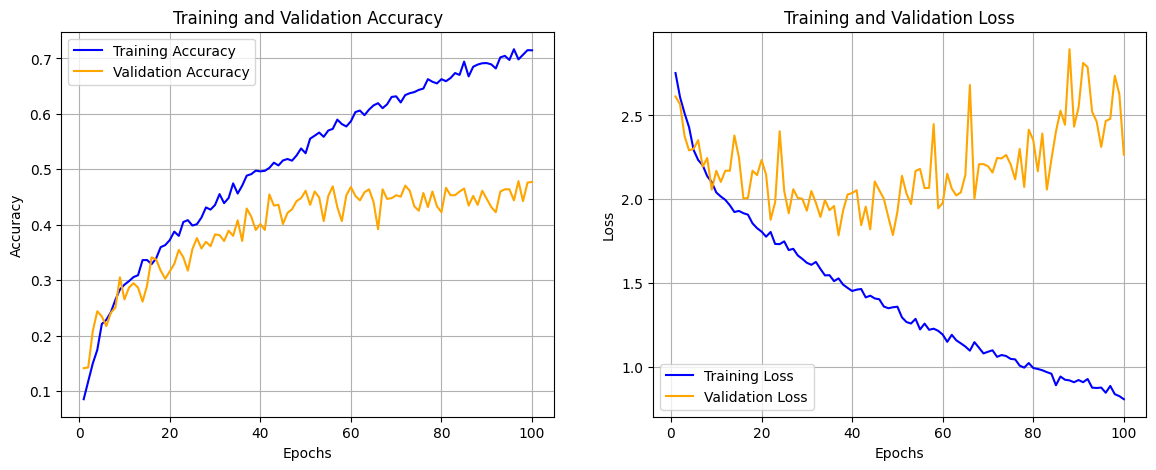


Confusion Matrix Hesaplanıyor...


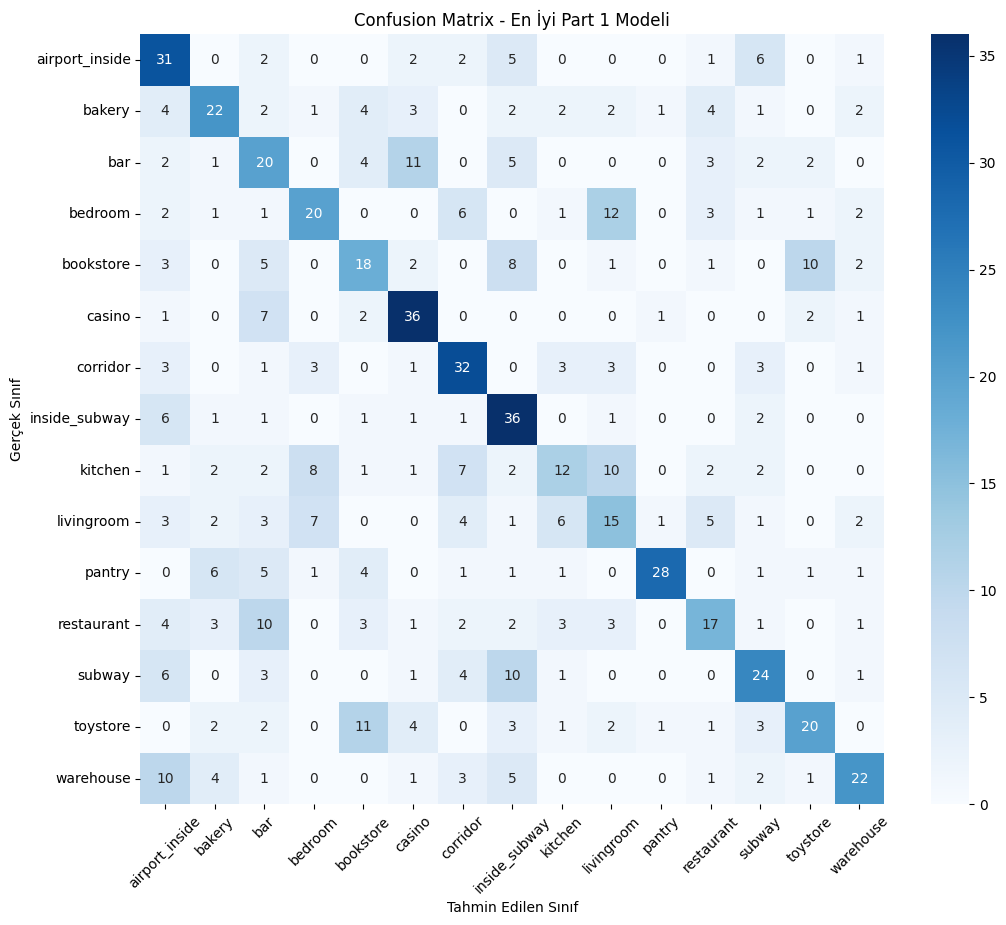


Classification Report:

                precision    recall  f1-score   support

airport_inside       0.41      0.62      0.49        50
        bakery       0.50      0.44      0.47        50
           bar       0.31      0.40      0.35        50
       bedroom       0.50      0.40      0.44        50
     bookstore       0.38      0.36      0.37        50
        casino       0.56      0.72      0.63        50
      corridor       0.52      0.64      0.57        50
 inside_subway       0.45      0.72      0.55        50
       kitchen       0.40      0.24      0.30        50
    livingroom       0.31      0.30      0.30        50
        pantry       0.88      0.56      0.68        50
    restaurant       0.45      0.34      0.39        50
        subway       0.49      0.48      0.48        50
      toystore       0.54      0.40      0.46        50
     warehouse       0.61      0.44      0.51        50

      accuracy                           0.47       750
     macro avg       

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import os
import tensorflow as tf

# 1. En İyi Modelin Loss ve Accuracy Grafiklerini Çizdirme
if 'best_history' in locals() and best_history:
    epochs_range = range(1, len(best_history['accuracy']) + 1)

    plt.figure(figsize=(14, 5))

    # Accuracy Grafiği
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, best_history['accuracy'], label='Training Accuracy', color='blue')
    plt.plot(epochs_range, best_history['val_accuracy'], label='Validation Accuracy', color='orange')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss Grafiği
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, best_history['loss'], label='Training Loss', color='blue')
    plt.plot(epochs_range, best_history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.show()

# 2. Confusion Matrix Oluşturma
print("\nConfusion Matrix Hesaplanıyor...")
best_model = tf.keras.models.load_model('best_model_part1.keras')

class_names = sorted(os.listdir('processed_data/train'))

y_true = []
y_pred = []

# Test veri seti üzerinden tahminleri toplama
for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

# Confusion Matrix Çizimi
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix - En İyi Part 1 Modeli')
plt.xlabel('Tahmin Edilen Sınıf')
plt.ylabel('Gerçek Sınıf')
plt.xticks(rotation=45)
plt.show()

# İstatistiksel Sınıflandırma Raporu (Precision, Recall, F1-Score)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

### Adım 7: VGG-16'yı İçe Aktarma ve İlk Eğitim (Feature Extraction)
Bu hücrede VGG-16 modelini internetten indirecek, ağırlıklarını donduracak ve kendi oluşturduğumuz sınıflandırıcı (Fully Connected) katmanlarını ekleyecğiz.

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
import tensorflow as tf

print("VGG-16 modeli indiriliyor...")
# include_top=False: VGG16'nın orijinal 1000 sınıflı FC katmanlarını atıyoruz.
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 1. Aşama için VGG-16'nın tüm konvolüsyon katmanlarını donduruyoruz (Eğitilmeyecekler)
base_model.trainable = False

# Yeni modelimiz
inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs) # Part 1'de tanımladığımız veri artırma

# VGG-16'nın kendi özel veri ön işleme fonksiyonu
x = tf.keras.applications.vgg16.preprocess_input(x)

# Dondurulmuş VGG-16 tabanı
x = base_model(x, training=False)

# Kendi Sınıflandırma Katmanlarımız (Classification Head)
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(15, activation='softmax')(x) # Bizim 15 Sınıfımız

vgg_model = tf.keras.Model(inputs, outputs)

# Modeli derleme
vgg_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

print("\nModel Özeti (Sadece en alttaki katmanların 'Trainable' olduğuna dikkat et):")
vgg_model.summary()

# 1. Aşama Eğitimi (Feature Extraction)
print("\n--- Feature Extraction Eğitimi Başlıyor ---")
history_vgg_feature = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

# Test seti üzerinde değerlendirme
test_loss, test_acc = vgg_model.evaluate(test_ds)
print(f"\nFeature Extraction Sonucu - Test Accuracy: {test_acc:.4f}")

VGG-16 modeli indiriliyor...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

Model Özeti (Sadece en alttaki katmanların 'Trainable' olduğuna dikkat et):


Model: "functional_33"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_28      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_28[0… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[26][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[26][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[26][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_26          │ (None, 25088)     │          0 │ vgg16[0][0]       │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_52 (Dense)    │ (None, 256)       │  6,422,784 │ flatten_26[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_26          │ (None, 256)       │          0 │ dense_52[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_53 (Dense)    │ (None, 15)        │      3,855 │ dropout_26[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 21,141,327 (80.65 MB)

 Trainable params: 6,426,639 (24.52 MB)

 Non-trainable params: 14,714,688 (56.13 MB)


--- Feature Extraction Eğitimi Başlıyor ---
Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 38s 619ms/step - accuracy: 0.1003 - loss: 6.8810 - val_accuracy: 0.2240 - val_loss: 2.5961
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 340ms/step - accuracy: 0.1380 - loss: 2.6253 - val_accuracy: 0.2747 - val_loss: 2.2383
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 336ms/step - accuracy: 0.1743 - loss: 2.5336 - val_accuracy: 0.2960 - val_loss: 2.3954
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 344ms/step - accuracy: 0.1820 - loss: 2.5020 - val_accuracy: 0.3800 - val_loss: 2.1759
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 351ms/step - accuracy: 0.1910 - loss: 2.4715 - val_accuracy: 0.4107 - val_loss: 2.1930
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 352ms/step - accuracy: 0.1870 - loss: 2.4512 - val_accuracy: 0.3613 - val_loss: 2.1536
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 348ms/step - accuracy: 0.2203 - loss: 2.4064 - val_accuracy: 0.4040 - val_loss: 1.9668
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 345ms/step

### Adım 8: Fine-Tuning
İlk eğitimde kendi eklediğimiz katmanlar belli ağırlıklara ulaştı. Şimdi VGG-16'nın son konvolüsyon bloğunu (Block 5) kullanıyoruz. Ödev yönergesinde de bahsedildiği gibi, bu aşamada ağırlıkları tamamen bozmamak için çok daha küçük bir learning rate (örn: 1e-5) kullanılmıştır.

In [ ]:
print("VGG-16 katmanları Fine-Tuning için açılıyor...")

# VGG-16'nın tamamını aç
base_model.trainable = True


set_trainable = False
for layer in base_model.layers:
    if layer.name == 'block5_conv1':
        set_trainable = True
    if set_trainable:
        layer.trainable = True
    else:
        layer.trainable = False


vgg_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# Fine Tuning Eğitimi (Üzerine 20 Epoch daha ekle)
print("\n--- Fine-Tuning Eğitimi Başlıyor ---")
history_vgg_fine = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

# Son Değerlendirme
test_loss_ft, test_acc_ft = vgg_model.evaluate(test_ds)
print(f"\nFine-Tuning Sonrası Sonuç - Test Accuracy: {test_acc_ft:.4f}")

# Eğitilmiş final modelini kaydet
vgg_model.save('best_model_part2_vgg16.keras')
print("Part 2 VGG-16 Modeli başarıyla kaydedildi!")

VGG-16 katmanları Fine-Tuning için açılıyor...

--- Fine-Tuning Eğitimi Başlıyor ---
Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 402ms/step - accuracy: 0.3000 - loss: 2.1095 - val_accuracy: 0.5147 - val_loss: 1.8346
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 406ms/step - accuracy: 0.3133 - loss: 2.0881 - val_accuracy: 0.5027 - val_loss: 1.8081
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 18s 388ms/step - accuracy: 0.3203 - loss: 2.0240 - val_accuracy: 0.5293 - val_loss: 1.7353
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 18s 376ms/step - accuracy: 0.3417 - loss: 2.0111 - val_accuracy: 0.5240 - val_loss: 1.8108
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 18s 377ms/step - accuracy: 0.3487 - loss: 1.9732 - val_accuracy: 0.5213 - val_loss: 1.6903
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 18s 385ms/step - accuracy: 0.3407 - loss: 1.9937 - val_accuracy: 0.5467 - val_loss: 1.7157
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 18s 390ms/step - accuracy: 0.3483 - loss: 1.9597 - val_accuracy: 0.5413 - val_loss: 1.7473
Epoch 8/20
4

### Adım 9: Raccoon Veri Setinin İndirilmesi

In [ ]:
import os
# Orijinal Raccoon veri setini GitHub'dan doğrudan indir
!git clone https://github.com/experiencor/raccoon_dataset.git
print("Raccoon veri seti başarıyla indirildi!")

Cloning into 'raccoon_dataset'...
remote: Enumerating objects: 646, done.
remote: Counting objects: 100% (646/646), done.
remote: Compressing objects: 100% (232/232), done.
remote: Total 646 (delta 413), reused 643 (delta 412), pack-reused 0 (from 0)
Receiving objects: 100% (646/646), 48.00 MiB | 7.24 MiB/s, done.
Resolving deltas: 100% (413/413), done.
Raccoon veri seti başarıyla indirildi!


### Adım 10: Veri Ön İşleme (XML Ayrıştırma ve Ölçekleme)
Raccoon veri setinde resimlerin yanında, bounding box koordinatlarını tutan XML dosyaları bulunur. Bu hücrede XML dosyalarını okuyacak, görüntüleri 224x224 boyutuna getirecek ve koordinatları 0 ile 1 arasına ölçekleyeceğiz.

In [ ]:
import cv2
import numpy as np
import xml.etree.ElementTree as ET
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

IMG_SIZE = 224
image_dir = 'raccoon_dataset/images'
annot_dir = 'raccoon_dataset/annotations'

images = []
boxes = []
labels = []

print("XML dosyaları okunuyor ve veriler işleniyor...")

for annot_file in os.listdir(annot_dir):
    if not annot_file.endswith('.xml'): continue

    # XML dosyasını parse et
    tree = ET.parse(os.path.join(annot_dir, annot_file))
    root = tree.getroot()

    img_name = root.find('filename').text
    img_path = os.path.join(image_dir, img_name)
    if not os.path.exists(img_path): continue

    # Resmi oku
    img = cv2.imread(img_path)
    if img is None: continue
    h, w, _ = img.shape

    # Bounding Box koordinatlarını çek
    bndbox = root.find('object').find('bndbox')
    xmin = int(bndbox.find('xmin').text)
    ymin = int(bndbox.find('ymin').text)
    xmax = int(bndbox.find('xmax').text)
    ymax = int(bndbox.find('ymax').text)

    # Resmi 224x224 boyutlandır ve normalize et (0-1 aralığı)
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_resized = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB) / 255.0

    # Kutu koordinatlarını 0-1 arasına oranla
    box = [xmin/w, ymin/h, xmax/w, ymax/h]

    images.append(img_resized)
    boxes.append(box)

    # Softmax Classification için One-Hot Encoding: [ArkaPlan, Rakun] -> Rakun olduğu için [0, 1]
    labels.append([0, 1])

# Numpy dizilerine çevir
images = np.array(images, dtype=np.float32)
boxes = np.array(boxes, dtype=np.float32)
labels = np.array(labels, dtype=np.float32)

# %80 Train, %20 Test olarak ayır
X_train, X_test, y_train_box, y_test_box, y_train_lbl, y_test_lbl = train_test_split(
    images, boxes, labels, test_size=0.2, random_state=42
)

print(f"Veri hazırlığı tamamlandı! Toplam Eğitim Görseli: {X_train.shape[0]}, Test Görseli: {X_test.shape[0]}")

XML dosyaları okunuyor ve veriler işleniyor...
Veri hazırlığı tamamlandı! Toplam Eğitim Görseli: 160, Test Görseli: 40


### Adım 11: ResNet Mimarisinin Kurulması
Ödevde ResNet18 istenmiş. Ancak Keras'ta ResNet18 native olarak bulunmadığından, mimari olarak aynı ailenin temsilcisi olan pre-trained ResNet50 kullanılmıştır.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50

print("Multi-Task ResNet modeli inşa ediliyor...")

# 1
base_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_resnet.trainable = False # İlk aşamada donduruyoruz

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_resnet(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)

# 2. Görev A: Sınıflandırma Başlığı (Classification Head)
class_head = layers.Dense(128, activation='relu')(x)
class_head = layers.Dropout(0.5)(class_head)
class_output = layers.Dense(2, activation='softmax', name='class_output')(class_head)

# 3. Görev B: Kutu Tahmin Başlığı (Regression/Localization Head)
box_head = layers.Dense(128, activation='relu')(x)
box_head = layers.Dense(64, activation='relu')(box_head)
box_output = layers.Dense(4, activation='sigmoid', name='box_output')(box_head)

# 4. Modeli Birleştirme
yolo_model = tf.keras.Model(inputs=inputs, outputs=[class_output, box_output])

# İki farklı Loss fonksiyonunu sözlük yapısında tanımlıyoruz
losses = {
    'class_output': 'categorical_crossentropy', # L_softmax
    'box_output': 'mse'                         # L_2
}

# Toplam Loss = 1.0 * L_softmax + 1.0 * L_2 (L_total)
loss_weights = {
    'class_output': 1.0,
    'box_output': 1.0
}

yolo_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=losses,
    loss_weights=loss_weights,
    metrics={'class_output': 'accuracy', 'box_output': 'mse'}
)

print("\n--- Multi-Task Model Eğitimi Başlıyor ---")
history_mt = yolo_model.fit(
    X_train,
    {'class_output': y_train_lbl, 'box_output': y_train_box},
    validation_data=(X_test, {'class_output': y_test_lbl, 'box_output': y_test_box}),
    epochs=25,
    batch_size=16
)

print("\nEğitim tamamlandı! Modeli kaydediyoruz...")
yolo_model.save('best_model_part3_resnet.keras')

Multi-Task ResNet modeli inşa ediliyor...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step

--- Multi-Task Model Eğitimi Başlıyor ---
Epoch 1/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - box_output_loss: 0.0380 - box_output_mse: 0.0380 - class_output_accuracy: 0.9688 - class_output_loss: 0.0959 - loss: 0.1339 - val_box_output_loss: 0.0190 - val_box_output_mse: 0.0202 - val_class_output_accuracy: 1.0000 - val_class_output_loss: 1.2182e-04 - val_loss: 0.0203
Epoch 2/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - box_output_loss: 0.0196 - box_output_mse: 0.0196 - class_output_accuracy: 1.0000 - class_output_loss: 3.3973e-04 - loss: 0.0200 - val_box_output_loss: 0.0182 - val_box_output_mse: 0.0193 - val_class_output_accuracy: 1.0000 - val_class_output_loss: 1.1464e-05 - val_loss: 0.0193
Epoch 3/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - box_output_loss: 0.0173 - box_output_mse: 0.0173 - class_output_accuracy: 1.0000 - class_output_loss: 9.8314e-05 - loss: 0.0174 - val_box_output_loss: 0.0

### Adım 12: Test Seti Üzerinde Tahmin ve MIoU Hesaplaması
IoU, gerçek kutu ile modelin tahmin ettiği kutunun ne kadar üst üste bindiğini ölçer. Bu hücre test setindeki tüm resimler için tahminde bulunup ortalama başarıyı (MIoU) hesaplayacaktır.

In [ ]:
import numpy as np

# IoU Hesaplama Fonksiyonu
def calculate_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    # Kesişim alanını hesapla
    interArea = max(0, xB - xA) * max(0, yB - yA)

    # İki kutunun da kendi alanlarını hesapla
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    # IoU = Kesişim Alanı / (Toplam Alan - Kesişim Alanı)
    iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)
    return iou

print("Test seti üzerinde tahminler yapılıyor...")
# Eğitilmiş modelden tahminleri al
preds = yolo_model.predict(X_test)
pred_classes = preds[0] # Softmax çıktıları
pred_boxes = preds[1]   # Bounding Box koordinatları

iou_scores = []

for i in range(len(X_test)):
    # Gerçek kutu ve tahmin edilen kutu
    ground_truth = y_test_box[i]
    prediction = pred_boxes[i]

    # İlgili resim için IoU değerini hesapla
    iou = calculate_iou(ground_truth, prediction)
    iou_scores.append(iou)

# Ortalama IoU (MIoU) değerini bul
miou = np.mean(iou_scores)
print(f"\nModelin Test Seti Üzerindeki Ortalama IoU (MIoU) Skoru: {miou:.4f}")

Test seti üzerinde tahminler yapılıyor...
2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 6s/step

Modelin Test Seti Üzerindeki Ortalama IoU (MIoU) Skoru: 0.5683


### Adım 13: Sonuçların Görselleştirilmesi
Bu hücre, test setinden rastgele resimler seçecek, gerçek kutuyu Yeşil, modelin tahmin ettiği kutuyu ise Kırmızı renkle çizdirerek sonucu gösterecektir.

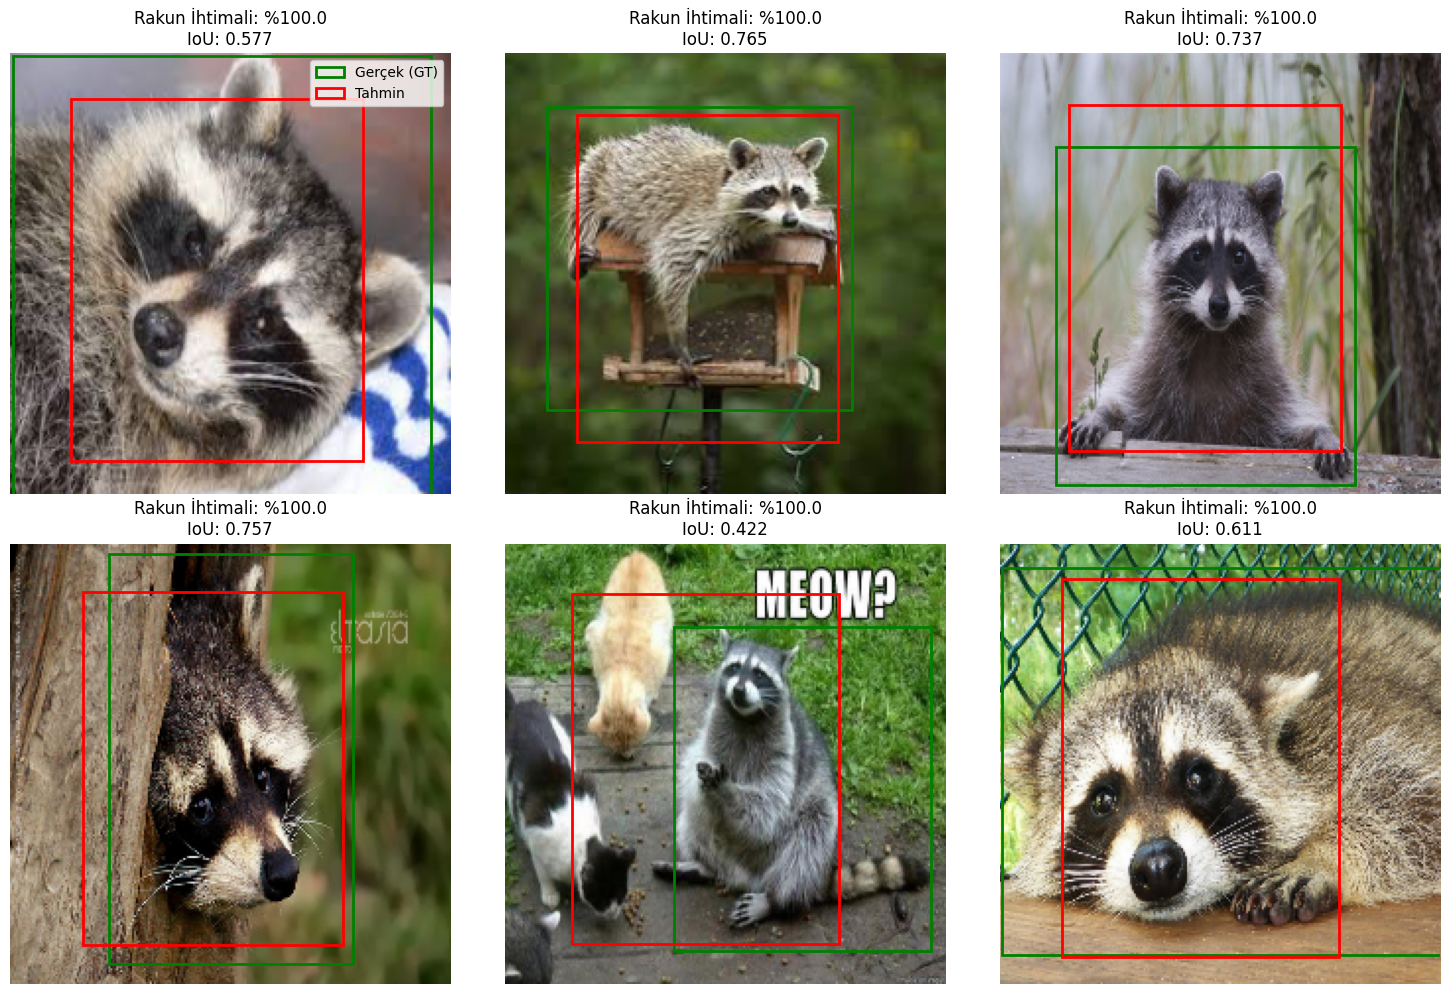

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

# Test setinden rastgele 6 resim seç
num_samples = 6
indices = random.sample(range(len(X_test)), num_samples)

plt.figure(figsize=(15, 10))

for i, idx in enumerate(indices):
    img = X_test[idx]
    gt_box = y_test_box[idx]
    pred_box = pred_boxes[idx]
    pred_prob = pred_classes[idx][1] # Rakun olma olasılığı (Softmax output)

    ax = plt.subplot(2, 3, i + 1)
    ax.imshow(img)

    h, w, _ = img.shape

    # Gerçek Kutu (Yeşil)
    gt_xmin, gt_ymin, gt_xmax, gt_ymax = gt_box[0]*w, gt_box[1]*h, gt_box[2]*w, gt_box[3]*h
    rect_gt = patches.Rectangle((gt_xmin, gt_ymin), gt_xmax - gt_xmin, gt_ymax - gt_ymin,
                                linewidth=2, edgecolor='green', facecolor='none', label='Gerçek (GT)')
    ax.add_patch(rect_gt)

    # Tahmin Edilen Kutu (Kırmızı)
    p_xmin, p_ymin, p_xmax, p_ymax = pred_box[0]*w, pred_box[1]*h, pred_box[2]*w, pred_box[3]*h
    rect_pred = patches.Rectangle((p_xmin, p_ymin), p_xmax - p_xmin, p_ymax - p_ymin,
                                  linewidth=2, edgecolor='red', facecolor='none', label='Tahmin')
    ax.add_patch(rect_pred)

    ax.set_title(f"Rakun İhtimali: %{pred_prob*100:.1f}\nIoU: {iou_scores[idx]:.3f}")
    ax.axis('off')
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.show()